# End-to-End Balance Sheet ML (Multi-Target) with ZenML

## Problem statement
Banks, suppliers, and public institutions often need to assess a company **before** engaging (loan, credit terms, contract, procurement).
The first reliable public signal is typically **financial statements**, especially the **balance sheet**.

### Goal
Build a deployable ML system to forecast **next-quarter balance-sheet dynamics** from historical balance-sheet data.

### Why this is useful
- **Solvency**: is the company becoming more/less resilient?
- **Liquidity**: is short-term payment risk rising?

### What we predict (multi-target)
We predict the next-period change (targets `y_*`) for:

**Solvency targets**
- Assets
- Liabilities
- Stockholders’ Equity

**Liquidity targets**
- Current Assets
- Current Liabilities
- Cash & Cash Equivalents

---

## MLOps / ZenML objective
This project is organized as a set of **ZenML pipelines**:
1. `data_pipeline`: extract + ingest SEC companyfacts into a long parquet dataset
2. `feature_pipeline`: build wide balance sheet table
3. `model_base_pipeline`: build lags + targets
4. `feature_ratio_pipeline`: add ratio features
5. `training_pipeline`: split → feature engineering → multi-target training → evaluation

The notebook demonstrates:
- EDA on raw & transformed data
- End-to-end pipeline execution
- Reproducible metrics artifacts
- Deployability discussion


In [1]:
import os, glob, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 160)

print("Working directory:", os.getcwd())


Working directory: d:\balance-sheet-ml


## Roadmap of the project (from data to deployment)

### A) Data layer
- Source: SEC Company Facts (XBRL-derived) data
- Pipeline:
  - Extract zip of JSONs
  - Parse them into a long-format dataset partitioned by company (CIK)
  - Run quality checks

### B) Feature layer
- Convert long-format (concept/value) into a wide table indexed by (cik, end)
- Choose “best filing” per quarter (latest filing date, amended preference, etc.)
- Keep USD unit, standard forms (10-Q, 10-K, and amendments)

### C) Modeling dataset
- Build lag features (`*_lag1`)
- Build prediction targets (`y_*`) as safe log-differences (fallback to raw diff)
- Add ratio features (liquidity/leverage/asset structure)

### D) Training & evaluation
- Chronological per-company split: train / val / test (from end)
- Train one model per target (multi-model multi-target)
- Evaluate MAE, RMSE, and Direction Accuracy
- Persist metrics + trained models as artifacts

### E) Deployability
- Config-driven pipelines
- Persisted artifacts
- Easy swap of ZenML stack (local → cloud)
- Ready for inference pipeline extension


## Controls: run mode 

This notebook can be used in two ways:

1) **Read-only grading (recommended):** run the notebook once, save outputs, and submit it with outputs.
2) **Re-run mode:** run selected pipeline cells. Some pipelines may be heavy depending on data size.

Below you can choose which pipelines to run.


In [2]:
# Toggle these for runtime control
RUN_DATA_PIPELINE = False          # can be heavy (zip extraction + ingestion)
RUN_FEATURE_PIPELINE = False       # wide table build (DuckDB pivot)
RUN_MODEL_BASE_PIPELINE = False    # lags + targets
RUN_RATIO_PIPELINE = False         # add ratios
RUN_TRAINING_PIPELINE = True       # most important for the demo

# Tip: for a fast demo run, keep only RUN_TRAINING_PIPELINE=True (if parquet artifacts exist)


In [3]:
import yaml

with open("pipelines_config.yaml", "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

cfg["pipelines"], cfg["training"]["target_cols"]


({'active': 'training'},
 ['y_Assets',
  'y_Liabilities',
  'y_StockholdersEquity',
  'y_AssetsCurrent',
  'y_LiabilitiesCurrent',
  'y_CashAndCashEquivalentsAtCarryingValue'])

## 1) EDA of “raw-ish” data (wide balance sheet table)

If the wide table exists (`data/interim/balance_sheet_wide.parquet`), we do EDA directly.
This represents the **raw balance sheet snapshot per company per quarter** after ingestion/pivot.

If it does not exist, you can run the feature pipeline first.


In [4]:
WIDE_PATH = cfg["model_base"]["wide_path"]
print("Wide path:", WIDE_PATH)
print("Exists?", os.path.exists(WIDE_PATH))

df_wide = None
if os.path.exists(WIDE_PATH):
    df_wide = pd.read_parquet(WIDE_PATH)
    print("wide shape:", df_wide.shape)
    display(df_wide.head(3))


Wide path: data/interim/balance_sheet_wide.parquet
Exists? True
wide shape: (462090, 27)


,cik,end,Assets,AssetsCurrent,AssetsNoncurrent,Liabilities,LiabilitiesCurrent,LiabilitiesNoncurrent,StockholdersEquity,LiabilitiesAndStockholdersEquity,CashAndCashEquivalentsAtCarryingValue,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,AccountsReceivableNetCurrent,InventoryNet,PrepaidExpenseCurrent,PropertyPlantAndEquipmentNet,Goodwill,IntangibleAssetsNetExcludingGoodwill,DebtCurrent,LongTermDebt,LongTermDebtCurrent,AccountsPayableCurrent,AccruedLiabilitiesCurrent,RetainedEarningsAccumulatedDeficit,CommonStockValue,AdditionalPaidInCapital,AccumulatedOtherComprehensiveIncomeLossNetOfTax
0,0000015847,2021-10-31,96976000.0,27851000.0,NaN,61385000.0,13882000.0,47503000.0,35591000.0,96976000.0,NaN,NaN,3566000.0,8459000.0,NaN,NaN,NaN,8045000.0,NaN,NaN,5041000.0,2743000.0,NaN,25636000.0,NaN,11078000.0,NaN
1,0000015847,2022-01-31,98076000.0,28328000.0,NaN,59661000.0,13460000.0,46201000.0,38415000.0,98076000.0,NaN,NaN,2172000.0,8649000.0,NaN,NaN,NaN,8087000.0,NaN,NaN,5070000.0,2312000.0,NaN,28320000.0,NaN,11218000.0,NaN
2,0000015847,2022-07-31,103966000.0,30478000.0,NaN,62219000.0,16608000.0,45611000.0,NaN,103966000.0,NaN,NaN,3615000.0,9321000.0,NaN,NaN,NaN,8084000.0,NaN,NaN,5054000.0,2736000.0,NaN,30379000.0,NaN,12640000.0,NaN


In [5]:
if df_wide is not None:
    df_wide["end"] = pd.to_datetime(df_wide["end"], errors="coerce")
    print("Companies:", df_wide["cik"].nunique())
    print("Date range:", df_wide["end"].min(), "→", df_wide["end"].max())
    print("Rows:", len(df_wide))


Companies: 14691
Date range: 1980-07-21 00:00:00 → 2027-12-31 00:00:00
Rows: 462090


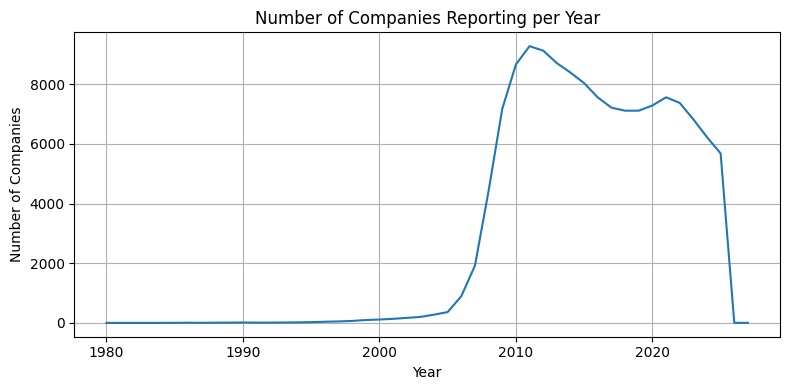

In [29]:
# Number of active companies per year
df_wide["year"] = df_wide["end"].dt.year

companies_per_year = (
    df_wide.groupby("year")["cik"]
    .nunique()
    .sort_index()
)

plt.figure(figsize=(8, 4))
companies_per_year.plot()
plt.title("Number of Companies Reporting per Year")
plt.ylabel("Number of Companies")
plt.xlabel("Year")
plt.grid(True)
plt.tight_layout()
plt.show()


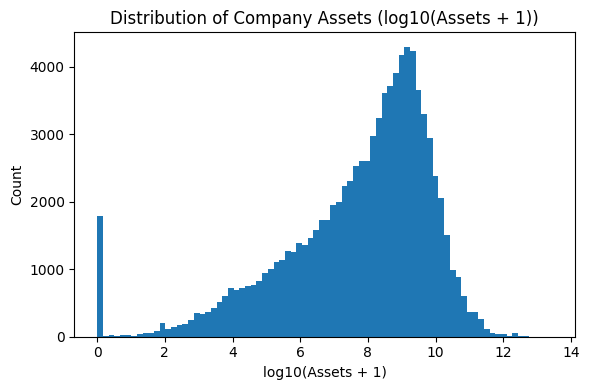

In [32]:
assets = df_wide["Assets"].dropna()
log_assets = np.log10(assets.clip(lower=0) + 1)

plt.figure(figsize=(6, 4))
plt.hist(log_assets, bins=80)
plt.title("Distribution of Company Assets (log10(Assets + 1))")
plt.xlabel("log10(Assets + 1)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


This distribution highlights the extreme heterogeneity in firm size, spanning several orders of magnitude. The heavy right tail motivates the use of log-transformations and ratio-based features to achieve scale-invariant modeling across companies.


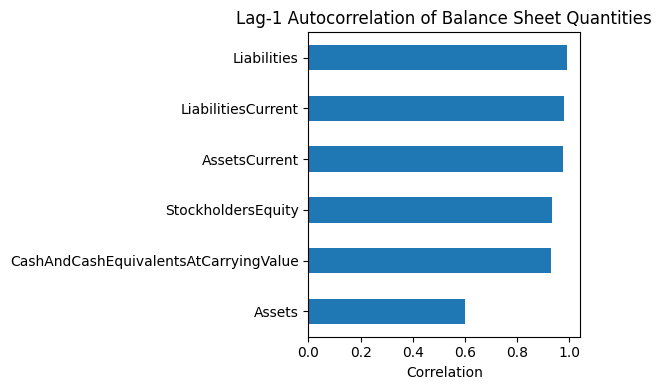

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

targets = [
    "Assets", "Liabilities", "StockholdersEquity",
    "AssetsCurrent", "LiabilitiesCurrent", "CashAndCashEquivalentsAtCarryingValue"
]

autocorr = {}

for c in targets:
    x = df_wide[c]
    x_lag = df_wide.groupby("cik")[c].shift(1)

    paired = pd.concat([x, x_lag], axis=1)
    paired.columns = ["x", "x_lag"]
    paired = paired.dropna()

    # guard against constant series (corr undefined)
    if paired["x"].nunique() < 2 or paired["x_lag"].nunique() < 2:
        autocorr[c] = np.nan
    else:
        autocorr[c] = paired["x"].corr(paired["x_lag"])

pd.Series(autocorr).sort_values().plot(kind="barh", figsize=(6, 4))
plt.title("Lag-1 Autocorrelation of Balance Sheet Quantities")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()


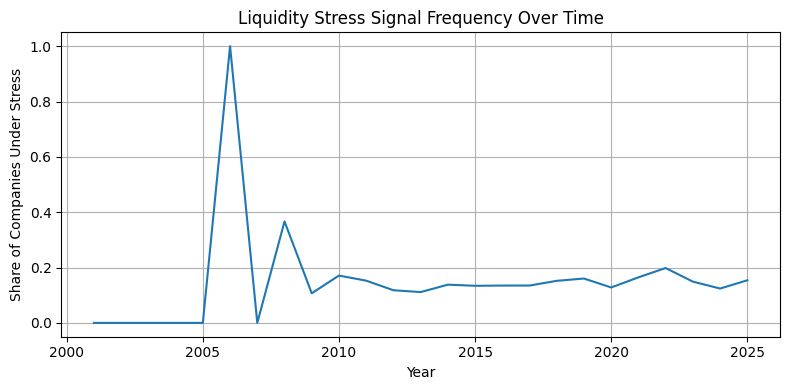

In [44]:
df_tmp = df.copy()
df_tmp["year"] = df_tmp["end"].dt.year

stress_flag = (
    (df_tmp["y_CashAndCashEquivalentsAtCarryingValue"] < 0) &
    (df_tmp["y_LiabilitiesCurrent"] > 0)
)

stress_rate = (
    df_tmp.assign(stress=stress_flag)
    .groupby("year")["stress"]
    .mean()
)

plt.figure(figsize=(8, 4))
plt.plot(stress_rate.index, stress_rate.values)
plt.title("Liquidity Stress Signal Frequency Over Time")
plt.xlabel("Year")
plt.ylabel("Share of Companies Under Stress")
plt.grid(True)
plt.tight_layout()
plt.show()


This plot shows the time variation in the share of companies exhibiting a liquidity stress signal. Spikes in early years reflect limited sample size, while later periods display a stable, non-zero stress rate, indicating that liquidity pressure is a persistent and cyclical feature of public firms rather than a rare anomaly.


## 2) EDA of transformed data (model-ready dataset)

Now we inspect the final training dataset:
`data/interim/balance_sheet_model_with_ratios.parquet`

This dataset includes:
- raw wide columns
- lag features (`*_lag1`)
- targets (`y_*`)
- ratio features (cash_to_assets, debt_to_assets, etc.)


In [54]:
MODEL_DATASET = cfg["training"]["dataset_path"]
print("Model dataset path:", MODEL_DATASET)
print("Exists?", os.path.exists(MODEL_DATASET))

df = pd.read_parquet(MODEL_DATASET)
print("shape:", df.shape)
display(df.head(10))


Model dataset path: data/interim/balance_sheet_model_with_ratios.parquet data/interim/balance_sheet_model_with_ratios.parquet
Exists? True True
shape: (72575, 113) (72575, 113)


,cik,end,Assets,AssetsCurrent,AssetsNoncurrent,Liabilities,LiabilitiesCurrent,LiabilitiesNoncurrent,StockholdersEquity,LiabilitiesAndStockholdersEquity,CashAndCashEquivalentsAtCarryingValue,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,AccountsReceivableNetCurrent,InventoryNet,PrepaidExpenseCurrent,PropertyPlantAndEquipmentNet,Goodwill,IntangibleAssetsNetExcludingGoodwill,DebtCurrent,LongTermDebt,LongTermDebtCurrent,AccountsPayableCurrent,AccruedLiabilitiesCurrent,RetainedEarningsAccumulatedDeficit,CommonStockValue,AdditionalPaidInCapital,AccumulatedOtherComprehensiveIncomeLossNetOfTax,Assets_lag1,AssetsCurrent_lag1,AssetsNoncurrent_lag1,Liabilities_lag1,LiabilitiesCurrent_lag1,LiabilitiesNoncurrent_lag1,StockholdersEquity_lag1,LiabilitiesAndStockholdersEquity_lag1,CashAndCashEquivalentsAtCarryingValue_lag1,CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_lag1,AccountsReceivableNetCurrent_lag1,InventoryNet_lag1,PrepaidExpenseCurrent_lag1,PropertyPlantAndEquipmentNet_lag1,Goodwill_lag1,IntangibleAssetsNetExcludingGoodwill_lag1,DebtCurrent_lag1,LongTermDebt_lag1,LongTermDebtCurrent_lag1,AccountsPayableCurrent_lag1,AccruedLiabilitiesCurrent_lag1,RetainedEarningsAccumulatedDeficit_lag1,CommonStockValue_lag1,AdditionalPaidInCapital_lag1,AccumulatedOtherComprehensiveIncomeLossNetOfTax_lag1,y_Assets,y_Assets_is_log,y_AssetsCurrent,y_AssetsCurrent_is_log,y_AssetsNoncurrent,y_AssetsNoncurrent_is_log,y_Liabilities,y_Liabilities_is_log,y_LiabilitiesCurrent,y_LiabilitiesCurrent_is_log,y_LiabilitiesNoncurrent,y_LiabilitiesNoncurrent_is_log,y_StockholdersEquity,y_StockholdersEquity_is_log,y_LiabilitiesAndStockholdersEquity,y_LiabilitiesAndStockholdersEquity_is_log,y_CashAndCashEquivalentsAtCarryingValue,y_CashAndCashEquivalentsAtCarryingValue_is_log,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents,y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_is_log,y_AccountsReceivableNetCurrent,y_AccountsReceivableNetCurrent_is_log,y_InventoryNet,y_InventoryNet_is_log,y_PrepaidExpenseCurrent,y_PrepaidExpenseCurrent_is_log,y_PropertyPlantAndEquipmentNet,y_PropertyPlantAndEquipmentNet_is_log,y_Goodwill,y_Goodwill_is_log,y_IntangibleAssetsNetExcludingGoodwill,y_IntangibleAssetsNetExcludingGoodwill_is_log,y_DebtCurrent,y_DebtCurrent_is_log,y_LongTermDebt,y_LongTermDebt_is_log,y_LongTermDebtCurrent,y_LongTermDebtCurrent_is_log,y_AccountsPayableCurrent,y_AccountsPayableCurrent_is_log,y_AccruedLiabilitiesCurrent,y_AccruedLiabilitiesCurrent_is_log,y_RetainedEarningsAccumulatedDeficit,y_RetainedEarningsAccumulatedDeficit_is_log,y_CommonStockValue,y_CommonStockValue_is_log,y_AdditionalPaidInCapital,y_AdditionalPaidInCapital_is_log,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax,y_AccumulatedOtherComprehensiveIncomeLossNetOfTax_is_log,cash_to_assets,current_assets_to_assets,liab_to_assets,equity_to_assets,current_liab_to_liab,ppe_to_assets,goodwill_to_assets,intangibles_to_assets,wc_to_assets,debt_to_assets,debt_to_equity
0,0000001750,2025-02-28,2.859100e+09,1.534800e+09,NaN,NaN,5.452000e+08,1.131300e+09,NaN,2.859100e+09,8.440000e+07,1.009000e+08,NaN,7.757000e+08,NaN,1.534000e+08,5.284000e+08,2.236000e+08,NaN,NaN,NaN,278900000.0,236700000.0,9.354000e+08,4.530000e+07,NaN,-1.210000e+07,2.849300e+09,1.498000e+09,NaN,NaN,5.583000e+08,1.109400e+09,NaN,2.849300e+09,6.170000e+07,8.250000e+07,NaN,7.900000e+08,NaN,1.670000e+08,5.432000e+08,2.273000e+08,NaN,NaN,NaN,291800000.0,258800000.0,9.443000e+08,4.530000e+07,NaN,-1.060000e+07,0.003434,1,0.024269,1,NaN,0,NaN,0,-0.023744,1,0.019548,1,NaN,0,0.003434,1,0.313283,1,0.201332,1,NaN,0,-0.018267,1,NaN,0,-0.084945,1,-0.027624,1,-0.016412,1,NaN,0,NaN,0,NaN,0,-0.045215,1,-0.089262,1,-0.009470,1,0.000000,1,NaN,0,-3.0,0,0.029520,0.536812,NaN,NaN,NaN,0.053653,0.184813,0.078206,0.346123,0.000000,NaN
1,0000001750,2025-05-31,2.844600e+09,1.510600e+09,NaN,1.633000e+09,5.547000e+08,1.078300e+09,1.211600e+09,2.844600e+09,9.650000e+07,1.092000e+08,NaN,8.092000e+08,NaN,1.585000e+0

In [8]:
df["end"] = pd.to_datetime(df["end"], errors="coerce")
print("Companies:", df["cik"].nunique())
print("Date range:", df["end"].min(), "→", df["end"].max())
print("Rows:", len(df))


Companies: 14307
Date range: 2001-12-31 00:00:00 → 2025-11-01 00:00:00
Rows: 72575


In [9]:
lag_cols = sorted([c for c in df.columns if c.endswith("_lag1")])
y_cols = sorted([c for c in df.columns if c.startswith("y_") and not c.endswith("_is_log")])
ratio_cols = sorted([c for c in df.columns if ("_to_" in c) or ("ratio" in c.lower())])

print("Lag features:", len(lag_cols), "| example:", lag_cols[:8])
print("Targets y_*:", len(y_cols), "| example:", y_cols[:10])
print("Ratio-like:", len(ratio_cols), "| example:", ratio_cols[:12])


Lag features: 25 | example: ['AccountsPayableCurrent_lag1', 'AccountsReceivableNetCurrent_lag1', 'AccruedLiabilitiesCurrent_lag1', 'AccumulatedOtherComprehensiveIncomeLossNetOfTax_lag1', 'AdditionalPaidInCapital_lag1', 'AssetsCurrent_lag1', 'AssetsNoncurrent_lag1', 'Assets_lag1']
Targets y_*: 25 | example: ['y_AccountsPayableCurrent', 'y_AccountsReceivableNetCurrent', 'y_AccruedLiabilitiesCurrent', 'y_AccumulatedOtherComprehensiveIncomeLossNetOfTax', 'y_AdditionalPaidInCapital', 'y_Assets', 'y_AssetsCurrent', 'y_AssetsNoncurrent', 'y_CashAndCashEquivalentsAtCarryingValue', 'y_CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents']
Ratio-like: 11 | example: ['cash_to_assets', 'current_assets_to_assets', 'current_liab_to_liab', 'debt_to_assets', 'debt_to_equity', 'equity_to_assets', 'goodwill_to_assets', 'intangibles_to_assets', 'liab_to_assets', 'ppe_to_assets', 'wc_to_assets']


### 2.1 Target availability analysis (why these targets)

We selected these targets because they reflect solvency + liquidity and have reasonable coverage:
- y_Assets, y_Liabilities, y_StockholdersEquity
- y_AssetsCurrent, y_LiabilitiesCurrent, y_CashAndCashEquivalentsAtCarryingValue

We exclude targets that are not reliably present (e.g., NetIncome, raw TotalDebt levels).


In [10]:
target_cols = cfg["training"]["target_cols"]

missing = [t for t in target_cols if t not in df.columns]
print("Missing training targets:", missing)

avail = df[target_cols].notna().mean().sort_values(ascending=False)
pd.DataFrame({"non_null_rate": avail, "non_null_count": df[target_cols].notna().sum()})


Missing training targets: []


,non_null_rate,non_null_count
y_Assets,1.000000,72575
y_AssetsCurrent,0.671788,48755
y_CashAndCashEquivalentsAtCarryingValue,0.665822,48322
y_Liabilities,0.931850,67629
y_LiabilitiesCurrent,0.680909,49417
y_StockholdersEquity,0.931850,67629


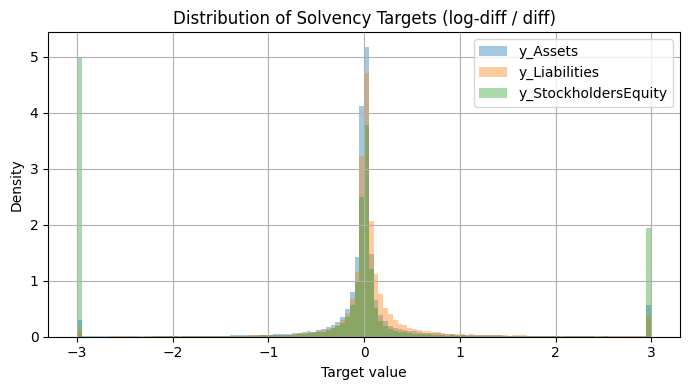

In [34]:
plt.figure(figsize=(7, 4))
for t in ["y_Assets", "y_Liabilities", "y_StockholdersEquity"]:
    df[t].dropna().hist(
        bins=120,
        alpha=0.4,
        label=t,
        density=True
    )

plt.legend()
plt.title("Distribution of Solvency Targets (log-diff / diff)")
plt.xlabel("Target value")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


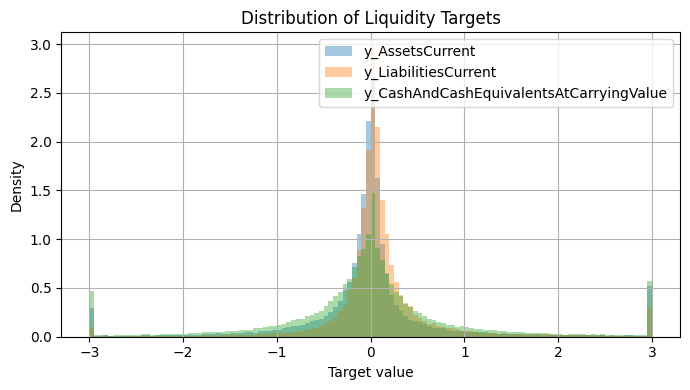

In [35]:
plt.figure(figsize=(7, 4))
for t in [
    "y_AssetsCurrent",
    "y_LiabilitiesCurrent",
    "y_CashAndCashEquivalentsAtCarryingValue",
]:
    df[t].dropna().hist(
        bins=120,
        alpha=0.4,
        label=t,
        density=True
    )

plt.legend()
plt.title("Distribution of Liquidity Targets")
plt.xlabel("Target value")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


These distributions are sharply peaked around zero with heavy tails, indicating that most firms experience small quarter-to-quarter changes, while extreme adjustments occur infrequently. The heavier tails for equity reflect its residual nature and higher sensitivity to shocks, motivating robust models and direction-focused evaluation.

Liquidity-related targets exhibit wider and more asymmetric tails, particularly for cash, highlighting higher short-term volatility. This behavior explains why magnitude errors are larger for liquidity variables while directional signals remain informative for early stress detection.


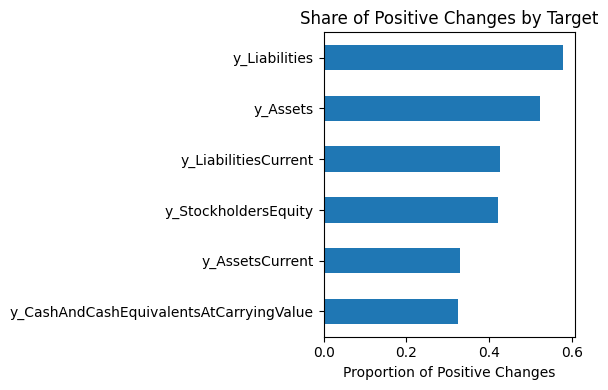

In [36]:
direction_balance = {
    t: (df[t] >= 0).mean()
    for t in target_cols
}

pd.Series(direction_balance).sort_values().plot(
    kind="barh",
    figsize=(6, 4)
)
plt.title("Share of Positive Changes by Target")
plt.xlabel("Proportion of Positive Changes")
plt.tight_layout()
plt.show()


## 3) How targets are constructed (from raw balance sheets)

Before training, raw balance-sheet values are transformed into **learning targets** (`y_*`)
inside the `build_model_base_step` function.

### Key design choices

1. **Lag-based forecasting**
   - For each financial concept (Assets, Liabilities, Equity, etc.), the model predicts the change from time *t → t+1*.
   - Input features include lagged values:
     \[
       X_{t-1}
     \]
   - The learning target at time *t* is defined as:
     \[
       y_t = f(X_t, X_{t-1})
     \]

2. **Safe log-difference transformation**
   - Targets are computed using a conditional transformation:
     \[
     y =
     \begin{cases}
     \log(X_t) - \log(X_{t-1}), & \text{if } X_t > 0 \text{ and } X_{t-1} > 0 \\
     X_t - X_{t-1},             & \text{otherwise}
     \end{cases}
     \]
   - This avoids undefined logarithms while preserving scale invariance when possible.

3. **Stability clipping**
   - Extreme changes are clipped to improve numerical stability and prevent exploding gradients:
     \[
       |\text{logdiff}| \le 3
     \]
   - This corresponds to an approximate **20× change cap**.

4. **Accounting reconciliation**
   - If two of the three balance-sheet components (Assets, Liabilities, Equity) are present,
     the third is imputed using the accounting identity:
     \[
       A = L + E
     \]

This design balances **financial realism** with **model stability**, ensuring well-behaved targets
while respecting fundamental accounting relationships.


In [16]:
# Verify target columns and log-diff flags exist
target_cols = cfg["training"]["target_cols"]

cols_to_check = []
for t in target_cols:
    cols_to_check.append(t)
    cols_to_check.append(f"{t}_is_log")

[c for c in cols_to_check if c in df.columns][:10], len(cols_to_check)


(['y_Assets',
  'y_Assets_is_log',
  'y_Liabilities',
  'y_Liabilities_is_log',
  'y_StockholdersEquity',
  'y_StockholdersEquity_is_log',
  'y_AssetsCurrent',
  'y_AssetsCurrent_is_log',
  'y_LiabilitiesCurrent',
  'y_LiabilitiesCurrent_is_log'],
 12)

### Interpreting the `*_is_log` flag

Each target has a companion flag:
- `y_XXX_is_log = 1` → log-difference was used
- `y_XXX_is_log = 0` → raw difference fallback

This allows the model to **learn differently** depending on scale regime
(e.g. small firms vs large firms, or distressed quarters).


In [17]:
log_usage = {}
for t in target_cols:
    flag = f"{t}_is_log"
    if flag in df.columns:
        log_usage[t] = df[flag].mean()

pd.DataFrame.from_dict(log_usage, orient="index", columns=["logdiff_usage_rate"])


,logdiff_usage_rate
y_Assets,0.961213
y_Liabilities,0.922894
y_StockholdersEquity,0.610968
y_AssetsCurrent,0.660834
y_LiabilitiesCurrent,0.678484
y_CashAndCashEquivalentsAtCarryingValue,0.647799


## 4) Feature engineering strategy

Feature engineering happens in **two layers**:

### A) Structural features (model base)
- Lagged values: `Assets_lag1`, `Liabilities_lag1`, etc.
- These capture **absolute scale and momentum**

### B) Financial ratios (feature engineering step)
Ratios encode **scale-invariant financial meaning**, e.g.:
- liquidity
- leverage
- capital structure
- asset composition

They are especially important when training across companies of very different sizes.


In [18]:
# Show example feature groups used by the model
lag_feats = sorted(c for c in df.columns if c.endswith("_lag1"))
ratio_base = [
    "cash_to_assets",
    "current_assets_to_assets",
    "liab_to_assets",
    "equity_to_assets",
    "current_liab_to_liab",
    "ppe_to_assets",
    "goodwill_to_assets",
    "intangibles_to_assets",
    "wc_to_assets",
    "debt_to_assets",
    "debt_to_equity",
]

print("Lag features (sample):", lag_feats[:8])
print("Base ratios present:", [r for r in ratio_base if r in df.columns])


Lag features (sample): ['AccountsPayableCurrent_lag1', 'AccountsReceivableNetCurrent_lag1', 'AccruedLiabilitiesCurrent_lag1', 'AccumulatedOtherComprehensiveIncomeLossNetOfTax_lag1', 'AdditionalPaidInCapital_lag1', 'AssetsCurrent_lag1', 'AssetsNoncurrent_lag1', 'Assets_lag1'] ['AccountsPayableCurrent_lag1', 'AccountsReceivableNetCurrent_lag1', 'AccruedLiabilitiesCurrent_lag1', 'AccumulatedOtherComprehensiveIncomeLossNetOfTax_lag1', 'AdditionalPaidInCapital_lag1', 'AssetsCurrent_lag1', 'AssetsNoncurrent_lag1', 'Assets_lag1']
Base ratios present: ['cash_to_assets', 'current_assets_to_assets', 'liab_to_assets', 'equity_to_assets', 'current_liab_to_liab', 'ppe_to_assets', 'goodwill_to_assets', 'intangibles_to_assets', 'wc_to_assets', 'debt_to_assets', 'debt_to_equity'] ['cash_to_assets', 'current_assets_to_assets', 'liab_to_assets', 'equity_to_assets', 'current_liab_to_liab', 'ppe_to_assets', 'goodwill_to_assets', 'intangibles_to_assets', 'wc_to_assets', 'debt_to_assets', 'debt_to_equity']


### Ratio dynamics & stability features

For each ratio, additional features are derived:
- 1-period delta
- 1-period percent change
- 4-period rolling mean
- 4-period rolling standard deviation

This allows the model to learn:
- short-term shocks
- medium-term stability vs volatility


d:\balance-sheet-ml\.venv\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\PC\AppData\Local\Temp\ipykernel_20568\1309719092.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tmp.groupby(pd.qcut(df_tmp["asset_size"], 5))


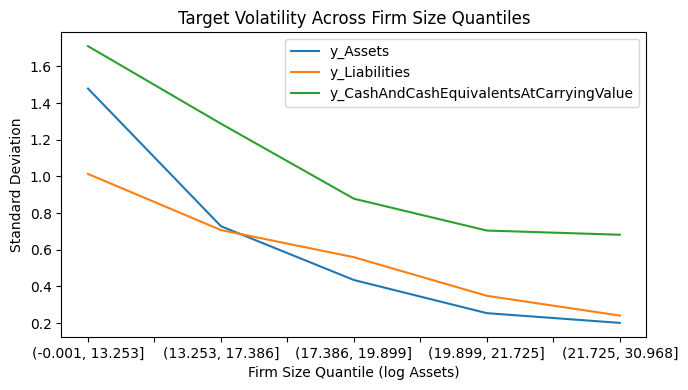

In [51]:
df_tmp = df.copy()
df_tmp["asset_size"] = np.log1p(df_tmp["Assets_lag1"])

vol = (
    df_tmp.groupby(pd.qcut(df_tmp["asset_size"], 5))
    [["y_Assets", "y_Liabilities", "y_CashAndCashEquivalentsAtCarryingValue"]]
    .std()
)

vol.plot(figsize=(7, 4))
plt.title("Target Volatility Across Firm Size Quantiles")
plt.ylabel("Standard Deviation")
plt.xlabel("Firm Size Quantile (log Assets)")
plt.tight_layout()
plt.show()


Target volatility decreases monotonically with firm size across all variables, indicating that smaller firms experience more unstable balance-sheet dynamics. The preservation of similar volatility patterns across size quantiles supports the use of scale-invariant transformations (log-differences and ratios) and pooled modeling across heterogeneous firms.


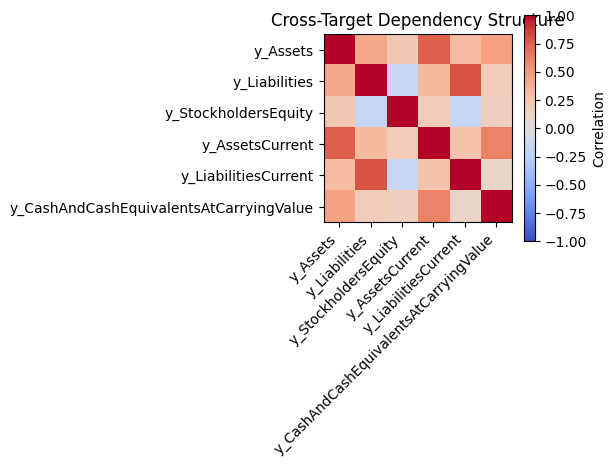

In [52]:
corr_targets = df[
    ["y_Assets", "y_Liabilities", "y_StockholdersEquity",
     "y_AssetsCurrent", "y_LiabilitiesCurrent", "y_CashAndCashEquivalentsAtCarryingValue"]
].corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr_targets, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_targets)), corr_targets.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_targets)), corr_targets.columns)
plt.title("Cross-Target Dependency Structure")
plt.tight_layout()
plt.show()


## 3) Training design

### Split strategy
We use a **per-company chronological split**:
- last `n_test` points → test
- previous `n_val` points → validation
- all earlier points → train

This avoids leakage and matches real forecasting: predicting future quarters from past quarters.

### Model strategy (multi-target)
Instead of a single multi-output model, we train **one model per target**:
- handles missingness naturally (drop NA per target)
- easy to evaluate each financial signal
- easy to deploy/monitor per target

### Algorithm
HistGradientBoostingRegressor (scikit-learn), with imputation + early stopping.


In [23]:
# Demonstrate how feature selection depends on the target
from steps.train_tree_step import _pick_features

example_target = target_cols[0]
example_features = _pick_features(df.dropna(subset=[example_target]), example_target)

len(example_features), example_features[:30]


(37,
 ['AccountsPayableCurrent_lag1',
  'AccountsReceivableNetCurrent_lag1',
  'AccruedLiabilitiesCurrent_lag1',
  'AccumulatedOtherComprehensiveIncomeLossNetOfTax_lag1',
  'AdditionalPaidInCapital_lag1',
  'AssetsCurrent_lag1',
  'AssetsNoncurrent_lag1',
  'Assets_lag1',
  'CashAndCashEquivalentsAtCarryingValue_lag1',
  'CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents_lag1',
  'CommonStockValue_lag1',
  'DebtCurrent_lag1',
  'Goodwill_lag1',
  'IntangibleAssetsNetExcludingGoodwill_lag1',
  'InventoryNet_lag1',
  'LiabilitiesAndStockholdersEquity_lag1',
  'LiabilitiesCurrent_lag1',
  'LiabilitiesNoncurrent_lag1',
  'Liabilities_lag1',
  'LongTermDebtCurrent_lag1',
  'LongTermDebt_lag1',
  'PrepaidExpenseCurrent_lag1',
  'PropertyPlantAndEquipmentNet_lag1',
  'RetainedEarningsAccumulatedDeficit_lag1',
  'StockholdersEquity_lag1',
  'cash_to_assets',
  'current_assets_to_assets',
  'liab_to_assets',
  'equity_to_assets',
  'current_liab_to_liab'])

## 4) Run ZenML pipelines end-to-end

We optionally run the whole chain:

- data_pipeline → feature_pipeline → model_base_pipeline → ratio_pipeline → training_pipeline

If artifacts already exist, you can skip heavy steps and run only training.


In [12]:
from run_pipeline import (
    run_data_pipeline,
    run_feature_pipeline,
    run_model_base_pipeline,
    run_ratio_pipeline,
    run_training_pipeline,
)

if RUN_DATA_PIPELINE:
    run_data_pipeline(cfg)

if RUN_FEATURE_PIPELINE:
    run_feature_pipeline(cfg)

if RUN_MODEL_BASE_PIPELINE:
    run_model_base_pipeline(cfg)

if RUN_RATIO_PIPELINE:
    run_ratio_pipeline(cfg)

if RUN_TRAINING_PIPELINE:
    run_training_pipeline(cfg)


Initiating a new run for the pipeline: training_pipeline.
Caching is disabled by default for training_pipeline.
Using user: default
Using stack: default
  orchestrator: default
  artifact_store: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step split_step has started.
[split_step] [split_step] dataset_path: data/interim/balance_sheet_model_with_ratios.parquet data/interim/balance_sheet_model_with_ratios.parquet
[split_step] [split_step] columns sample: ['cik', 'end', 'Assets', 'AssetsCurrent', 'AssetsNoncurrent', 'Liabilities', 'LiabilitiesCurrent', 'LiabilitiesNoncurrent', 'StockholdersEquity', 'LiabilitiesAndStockholdersEquity', 'CashAndCashEquivalentsAtCarryingValue', 'CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents', 'AccountsReceivableNetCurrent', 'InventoryNet', 'PrepaidExpenseCurrent', 'PropertyPlantAndEquipmentNet', 'Goodwill', 'IntangibleAssetsNetExcludingGoodwill', 'DebtCurrent',

## 5) Evaluation

The training pipeline writes a combined metrics file:
`data/interim/metrics/metrics_multi_*.json`

We load the latest file and present:
- MAE
- RMSE
- Direction Accuracy (sign correctness)


In [13]:
metric_files = sorted(glob.glob("data/interim/metrics/metrics_multi_*.json"))
if not metric_files:
    raise FileNotFoundError("No metrics_multi_*.json found. Run the training pipeline first.")

latest = metric_files[-1]
print("Latest metrics file:", latest)

with open(latest, "r", encoding="utf-8") as f:
    metrics = json.load(f)

rows = []
for t, m in metrics["metrics_by_target"].items():
    for split in ["val", "test"]:
        r = m[split]
        rows.append({
            "target": t,
            "split": split,
            "rows": r["rows"],
            "mae": r["mae"],
            "rmse": r["rmse"],
            "dir_acc": r["dir_acc"],
        })

df_metrics = pd.DataFrame(rows)
df_metrics = df_metrics.sort_values(["target", "split"])
df_metrics


Latest metrics file: data/interim/metrics\metrics_multi_1768380794.json data/interim/metrics\metrics_multi_1768380794.json


,target,split,rows,mae,rmse,dir_acc
1,y_Assets,test,25746,0.261433,0.528915,0.658588
0,y_Assets,val,9337,0.290112,0.570395,0.588090
7,y_AssetsCurrent,test,19675,0.320267,0.571414,0.709327
6,y_AssetsCurrent,val,6653,0.376183,0.634585,0.584999
11,y_CashAndCashEquivalentsAtCarryingValue,test,19792,0.350602,0.593730,0.812904
10,y_CashAndCashEquivalentsAtCarryingValue,val,6931,0.467457,0.697275,0.720098
3,y_Liabilities,test,25120,0.260277,0.487547,0.678145
2,y_Liabilities,val,8992,0.309432,0.549021,0.621997
9,y_LiabilitiesCurrent,test,19711,0.269808,0.513042,0.712191
8,y_LiabilitiesCurrent,val,6706,0.304519,0.555365,0.618998


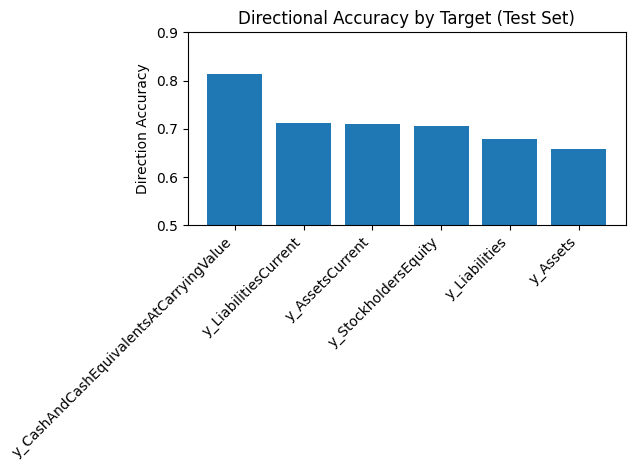

,target,split,rows,mae,rmse,dir_acc
11,y_CashAndCashEquivalentsAtCarryingValue,test,19792,0.350602,0.593730,0.812904
9,y_LiabilitiesCurrent,test,19711,0.269808,0.513042,0.712191
7,y_AssetsCurrent,test,19675,0.320267,0.571414,0.709327
5,y_StockholdersEquity,test,25120,0.726782,1.398916,0.706887
3,y_Liabilities,test,25120,0.260277,0.487547,0.678145
1,y_Assets,test,25746,0.261433,0.528915,0.658588


In [14]:
test = df_metrics[df_metrics["split"] == "test"].copy().sort_values("dir_acc", ascending=False)

plt.figure()
plt.bar(test["target"], test["dir_acc"])
plt.xticks(rotation=45, ha="right")
plt.title("Directional Accuracy by Target (Test Set)")
plt.ylabel("Direction Accuracy")
plt.ylim(0.5, 0.9)
plt.tight_layout()
plt.show()

test


Directional accuracy varies by target, with liquidity variables—especially cash—exhibiting the strongest predictability. This pattern suggests that short-term financial adjustments are more directionally stable than aggregate balance-sheet totals, reinforcing the use of directional metrics for risk-oriented evaluation.


### Interpreting metrics (finance perspective)

Financial time series are noisy; magnitude metrics (MAE/RMSE) can be large for volatile items (cash, equity).
For **risk monitoring**, the **direction** of change is often more actionable:

- Assets ↑ suggests growth/expansion
- Liabilities ↑ suggests leverage increasing (risk)
- Equity ↓ suggests buffer shrinking (risk)
- Current liabilities ↑ suggests short-term pressure
- Cash ↓ suggests liquidity stress

Therefore, Direction Accuracy provides an interpretable indicator of forecasting usefulness.


In [15]:
model_files = sorted(glob.glob("data/interim/models/*.joblib"))
print("Saved models:", len(model_files))
model_files[:10]


Saved models: 11 11


['data/interim/models\\baseline_ridge_y_Assets.joblib',
 'data/interim/models\\hgb_y_Assets.joblib',
 'data/interim/models\\hgb_y_AssetsCurrent_it900_lr0.03_d6.joblib',
 'data/interim/models\\hgb_y_Assets_it300_lr0.05_d8.joblib',
 'data/interim/models\\hgb_y_Assets_it600_lr0.05_d4.joblib',
 'data/interim/models\\hgb_y_Assets_it900_lr0.03_d6.joblib',
 'data/interim/models\\hgb_y_Assets_it900_lr0.03_d8.joblib',
 'data/interim/models\\hgb_y_CashAndCashEquivalentsAtCarryingValue_it900_lr0.03_d6.joblib',
 'data/interim/models\\hgb_y_LiabilitiesCurrent_it900_lr0.03_d6.joblib',
 'data/interim/models\\hgb_y_Liabilities_it900_lr0.03_d6.joblib']

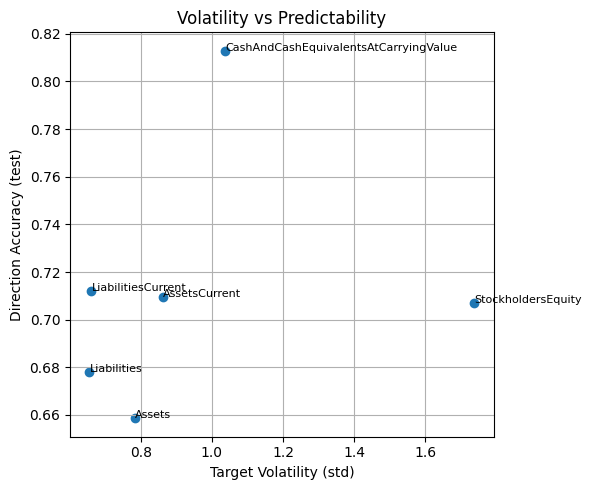

In [39]:
# Compute volatility (std) of targets
volatility = {
    t: df[t].std()
    for t in target_cols
}

vol_df = pd.DataFrame({
    "volatility": volatility,
})

# Merge with test direction accuracy
dir_acc = (
    df_metrics[df_metrics["split"] == "test"]
    .set_index("target")["dir_acc"]
)

vol_df["dir_acc"] = dir_acc

plt.figure(figsize=(6, 5))
plt.scatter(vol_df["volatility"], vol_df["dir_acc"])

for t in vol_df.index:
    plt.annotate(t.replace("y_", ""), 
                 (vol_df.loc[t, "volatility"], vol_df.loc[t, "dir_acc"]),
                 fontsize=8)

plt.xlabel("Target Volatility (std)")
plt.ylabel("Direction Accuracy (test)")
plt.title("Volatility vs Predictability")
plt.grid(True)
plt.tight_layout()
plt.show()


This plot illustrates that higher volatility does not necessarily imply lower directional predictability. In particular, cash exhibits both high volatility and high directional accuracy, highlighting that noisy financial signals can still provide robust early-warning information when evaluated in terms of direction rather than magnitude.


## 6) Inference Pipeline (Deployable Scoring)

To complete the end-to-end ML system, we add an **inference pipeline** that:
1. Loads the latest prepared dataset (`balance_sheet_model_with_ratios.parquet`)
2. Re-applies the same feature engineering used during training (ratio deltas, rolling stats)
3. Selects the **latest quarter per company**
4. Loads all trained models (`.joblib`) and generates predictions for each target
5. Saves predictions to `data/processed/predictions_latest.parquet`

This is the final “deployable” component: once new quarterly data arrives, we can rerun feature pipelines and then score the newest quarter automatically.


In [24]:
# Run inference pipeline (requires trained models in data/interim/models)
from pipelines.inference_pipeline import inference_pipeline

icfg = cfg.get("inference", {
    "dataset_path": "data/interim/balance_sheet_model_with_ratios.parquet",
    "models_dir": "data/interim/models",
    "out_path": "data/processed/predictions_latest.parquet",
    "mode": "latest_per_company",
})

inference_summary = inference_pipeline(
    dataset_path=icfg["dataset_path"],
    models_dir=icfg["models_dir"],
    out_path=icfg["out_path"],
    mode=icfg.get("mode", "latest_per_company"),
)

print("Inference summary:", inference_summary)


Initiating a new run for the pipeline: inference_pipeline.
Caching is disabled by default for inference_pipeline.
Using user: default
Using stack: default
  orchestrator: default
  artifact_store: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml login --local.
Step score_feature_engineering_step has started.
Step score_feature_engineering_step has finished in 8.999s.
Step predict_latest_step has started.
[predict_latest_step] [predict_latest_step] Saved predictions: data/processed/predictions_latest.parquet data/processed/predictions_latest.parquet
[predict_latest_step] [predict_latest_step] Saved summary: data\processed\predictions_latest.json data\processed\predictions_latest.json
Step predict_latest_step has finished in 3.774s.
Pipeline run has finished in 14.754s.
Inference summary: body=PipelineRunResponseBody(created=datetime.datetime(2026, 1, 14, 9, 25, 37, 467118), updated=datetime.datetime(2026, 1, 14, 9, 25, 52,

In [55]:
PRED_PATH = icfg["out_path"]
print("Predictions file exists?", os.path.exists(PRED_PATH), "->", PRED_PATH)

pred = pd.read_parquet(PRED_PATH)
print("pred shape:", pred.shape)
pred.head(10)


Predictions file exists? True -> data/processed/predictions_latest.parquet True -> data/processed/predictions_latest.parquet
pred shape: (5584, 8) (5584, 8)


,cik,end,pred_y_Assets,pred_y_AssetsCurrent,pred_y_CashAndCashEquivalentsAtCarryingValue,pred_y_Liabilities,pred_y_LiabilitiesCurrent,pred_y_StockholdersEquity
0,0000001750,2025-08-31,0.028344,0.043856,-0.172698,0.012451,-0.031956,0.025182
1,0000001800,2025-09-30,-0.052542,0.037626,0.076612,-0.060269,0.084736,0.013039
2,0000002098,2025-09-30,0.001972,-0.038207,-0.237639,-0.033944,-0.083156,0.014872
3,0000002186,2025-09-30,0.012062,0.019342,0.047870,0.053197,0.011748,0.037030
4,0000002488,2025-09-27,-0.043198,0.118928,0.033874,-0.063428,0.119483,-0.011272
5,0000002969,2025-09-30,-0.019253,-0.047780,-0.185394,0.022872,-0.094850,-0.001342
6,0000003197,2025-09-30,0.024805,0.041084,-0.099690,-0.001720,0.075043,0.020180
7,0000003453,2025-09-30,0.064843,-0.271087,-1.048485,-0.051003,-0.013192,0.000045
8,0000003499,2025-09-30,0.009530,-2.835159,0.008209,0.109641,-0.836627,0.014744
9,0000003545,2025-06-30,0.071782,0.366644,1.239838,0.126842,0.042346,0.021249


### Example: simple liquidity stress signal (interpretable)

A lightweight, interpretable alert rule (for suppliers/banks):

**Liquidity stress warning** if:
- predicted cash change is negative (cash decreasing), and
- predicted current liabilities change is positive (short-term burden increasing)

This rule is not a “final product”, but demonstrates how predictions can be turned into a deployable decision signal.


In [56]:
cash_col = "pred_y_CashAndCashEquivalentsAtCarryingValue"
cl_col = "pred_y_LiabilitiesCurrent"

if cash_col in pred.columns and cl_col in pred.columns:
    pred["liquidity_stress_flag"] = (pred[cash_col] < 0) & (pred[cl_col] > 0)

    print("Liquidity stress rate:", pred["liquidity_stress_flag"].mean())

    # Show a few flagged examples
    pred[pred["liquidity_stress_flag"]].head(15)
else:
    print("Required columns not found in predictions. Available pred columns:")
    print([c for c in pred.columns if c.startswith("pred_")])


Liquidity stress rate: 0.2645057306590258 0.2645057306590258


 ~24.5% of companies in the scored dataset are flagged as having a potential liquidity stress signal in the next period, according to our model.

### Deployability summary

With the inference pipeline, the project supports a full operational loop:

- **Training loop**: prepare dataset → train multi-target models → save artifacts
- **Scoring loop**: load latest quarter → apply feature engineering → predict targets → write predictions

This structure is ready to be scheduled (e.g., quarterly), monitored, and deployed by switching the ZenML stack to cloud services.
